In [1]:
!git clone https://github.com/AnanduDinesan/Facial-Expression-Recognition.git

fatal: destination path 'Facial-Expression-Recognition' already exists and is not an empty directory.


# =========================
# SECTION 1 — UPLOAD DATASET
# =========================

In [6]:
DATASET_PATH = "/content/Facial-Expression-Recognition/data"

In [4]:
import tensorflow as tf
import matplotlib.pyplot as plt

In [7]:
IMG_SIZE = 48
BATCH_SIZE = 64

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    DATASET_PATH+"/train",
    color_mode="grayscale",
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=True
)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    DATASET_PATH+"/test",
    color_mode="grayscale",
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False
)

Found 28709 files belonging to 7 classes.
Found 7178 files belonging to 7 classes.


In [8]:
class_names = train_ds.class_names
print(class_names)

['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


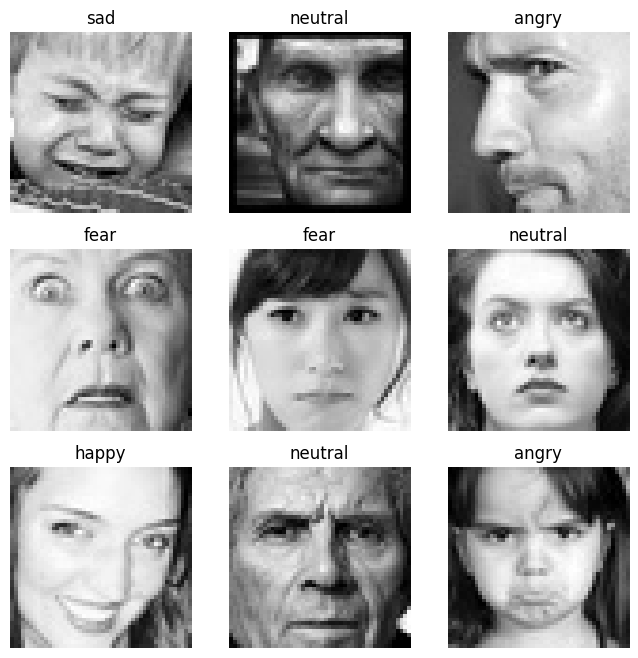

In [9]:
for images, labels in train_ds.take(1):
    plt.figure(figsize=(8,8))
    for i in range(9):
        ax = plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().squeeze(), cmap="gray")
        plt.title(class_names[labels[i].numpy().argmax()])
        plt.axis("off")
    plt.show()

# ==============================
# SECTION 2 — DATA ANALYSIS
# ==============================

In [10]:
import os
import numpy as np
import matplotlib.pyplot as plt

Class distribution: {'disgust': 436, 'happy': 7215, 'sad': 4830, 'angry': 3995, 'surprise': 3171, 'fear': 4097, 'neutral': 4965}


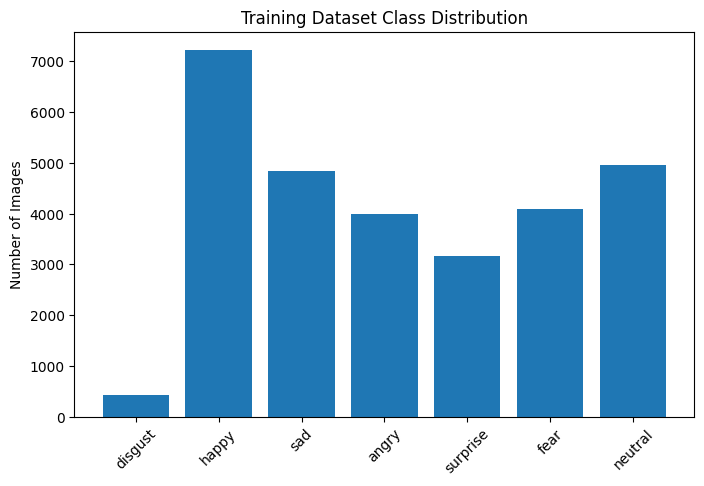

In [11]:
train_path = "/content/Facial-Expression-Recognition/data/train"

class_counts = {}

for cls in os.listdir(train_path):
    class_counts[cls] = len(os.listdir(os.path.join(train_path, cls)))

print("Class distribution:", class_counts)

plt.figure(figsize=(8,5))
plt.bar(class_counts.keys(), class_counts.values())
plt.title("Training Dataset Class Distribution")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.show()

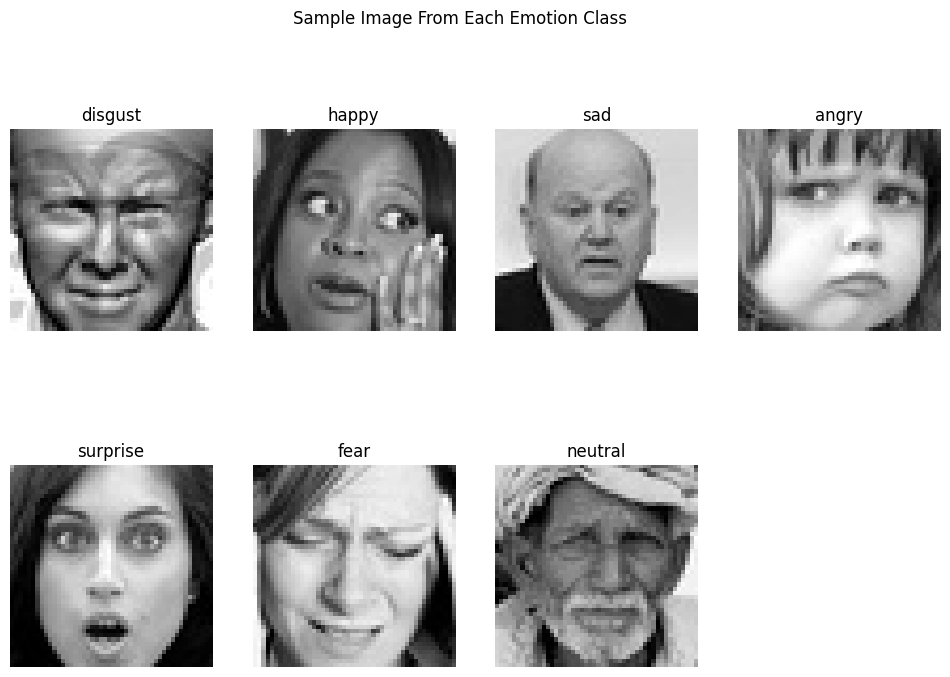

In [12]:
plt.figure(figsize=(12,8))

for i, cls in enumerate(class_counts.keys()):
    folder = os.path.join(train_path, cls)
    img_path = os.path.join(folder, os.listdir(folder)[0])
    img = plt.imread(img_path)

    ax = plt.subplot(2,4,i+1)
    plt.imshow(img, cmap="gray")
    plt.title(cls)
    plt.axis("off")

plt.suptitle("Sample Image From Each Emotion Class")
plt.show()

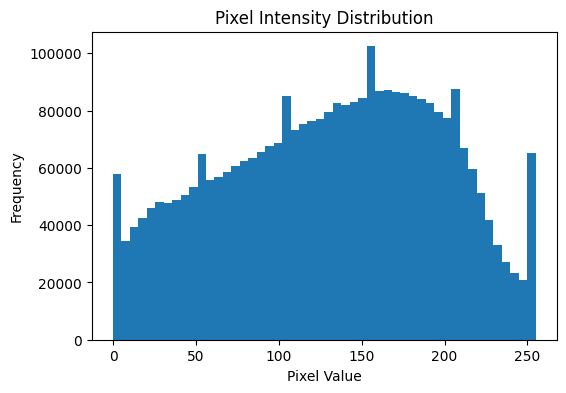

In [13]:
pixel_values = []

for cls in os.listdir(train_path):
    folder = os.path.join(train_path, cls)
    for img_name in os.listdir(folder)[:200]:   # sample only
        img = plt.imread(os.path.join(folder, img_name))
        pixel_values.extend(img.flatten())

plt.figure(figsize=(6,4))
plt.hist(pixel_values, bins=50)
plt.title("Pixel Intensity Distribution")
plt.xlabel("Pixel Value")
plt.ylabel("Frequency")
plt.show()

In [14]:
sizes = set()

for cls in os.listdir(train_path):
    folder = os.path.join(train_path, cls)
    for img_name in os.listdir(folder)[:50]:
        img = plt.imread(os.path.join(folder, img_name))
        sizes.add(img.shape)

print("Unique image sizes:", sizes)

Unique image sizes: {(48, 48)}


In [15]:
total_images = sum(class_counts.values())
num_classes = len(class_counts)

print(f"Total training images: {total_images}")
print(f"Number of emotion classes: {num_classes}")

Total training images: 28709
Number of emotion classes: 7


# =============================
# SECTION 3 — DATA PREPROCESSING
# =============================

In [16]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import os

In [17]:
labels = []

for i, cls in enumerate(class_names):
    folder = DATASET_PATH + "/train/" + cls
    labels += [i] * len(os.listdir(folder))

labels = np.array(labels)

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels),
    y=labels
)

class_weights = dict(enumerate(class_weights))

print("Class weights:", class_weights)

Class weights: {0: np.float64(1.0266046844269623), 1: np.float64(9.406618610747051), 2: np.float64(1.0010460615781582), 3: np.float64(0.5684387684387684), 4: np.float64(0.8260394187886635), 5: np.float64(0.8491274770777877), 6: np.float64(1.293372978330405)}


In [18]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(
    lambda x, y: (normalization_layer(x), y),
    num_parallel_calls=tf.data.AUTOTUNE
)
test_ds = test_ds.map(
    lambda x, y: (normalization_layer(x), y),
    num_parallel_calls=tf.data.AUTOTUNE
)

train_ds = train_ds.cache()
test_ds  = test_ds.cache()

In [19]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.08),
    tf.keras.layers.RandomZoom(0.1),
])

train_ds = train_ds.map(
    lambda x, y: (data_augmentation(x, training=True), y),
    num_parallel_calls=tf.data.AUTOTUNE
)

In [20]:
train_ds = train_ds.shuffle(buffer_size=100)
train_ds = train_ds.prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds  = test_ds.prefetch(buffer_size=tf.data.AUTOTUNE)

In [21]:
print("First pass — filling cache, this will be slow (1-3 min)...")

for images, labels_batch in train_ds.take(1):
    print("Batch shape:", images.shape)
    print("Labels shape:", labels_batch.shape)
    print("Pixel range: %.2f to %.2f" % (images.numpy().min(), images.numpy().max()))

print("Cache filled! All future iterations will be fast.")

First pass — filling cache, this will be slow (1-3 min)...
Batch shape: (64, 48, 48, 1)
Labels shape: (64, 7)
Pixel range: 0.00 to 1.00
Cache filled! All future iterations will be fast.
